In [1]:
# ============================================================
# MODELO QSAR — ALTA POTENCIA (re-entrenamiento)
# Nuevo umbral: Log10 EC50 ≤ 4.5 nM
# N = 750 moléculas (vs 232 anteriores — 3x más datos)
#
# Estrategia:
#   - Eliminar outliers extremos cola izquierda (Log10 < 2.1)
#   - Modelo ensemble directo (sin clustering — 90.5% unimodal)
#   - RF + ET + GB + SVM + comparativa
#   - Descriptores: ECFP4 + ECFP6 + MACCS + fisicoquímicos
# ============================================================

# ── CELDA 1 — Instalación ─────────────────────────────────────
!pip install rdkit --quiet
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 21.4 MB/s eta 0:00:00


In [2]:
# ── CELDA 2 — Imports ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
)
from sklearn.svm import SVR
from sklearn.mixture import GaussianMixture
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib, os

from google.colab import drive

RANDOM_SEED = 42
PALETTE_C   = ["#2196F3", "#FF9800", "#4CAF50"]   # azul/naranja/verde por cluster

In [3]:
# ── CELDA 3 — Cargar y filtrar datos ─────────────────────────
drive.mount('/content/drive')

RUTA_CSV = "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/EC50_molecules_reclassified.csv"

database = pd.read_csv(RUTA_CSV)
database['Log10 Value (nM)'] = pd.to_numeric(
    database['Log10 Value (nM)'], errors='coerce'
)

df = database[database['Log10 Value (nM)'] <= 4.5].copy()
df = df[['Molecule ChEMBL ID', 'Smiles', 'Log10 Value (nM)']].dropna()
df.columns = ['chembl_id', 'smiles', 'log10_ec50']
df = df.reset_index(drop=True)

# Eliminar outliers extremos cola izquierda
y_raw = df['log10_ec50'].values
Q1, Q3 = np.percentile(y_raw, 25), np.percentile(y_raw, 75)
lower  = Q1 - 2.5 * (Q3 - Q1)
df     = df[df['log10_ec50'] >= lower].reset_index(drop=True)

print(f"Alta Potencia (Log10 ≤ 4.5, sin outliers): {len(df)} moléculas")
print(df['log10_ec50'].describe().round(4))

Mounted at /content/drive
Alta Potencia (Log10 ≤ 4.5, sin outliers): 693 moléculas
count    693.0000
mean       3.9549
std        0.4192
min        2.2300
25%        3.7410
50%        4.0000
75%        4.2830
max        4.4990
Name: log10_ec50, dtype: float64



── Clustering GMM (n=3) ──
  Cluster 0: n= 101  media=3.186  std=0.317  rango=[2.230, 3.534]
  Cluster 1: n= 333  media=3.886  std=0.159  rango=[3.540, 4.155]
  Cluster 2: n= 259  media=4.344  std=0.100  rango=[4.157, 4.499]


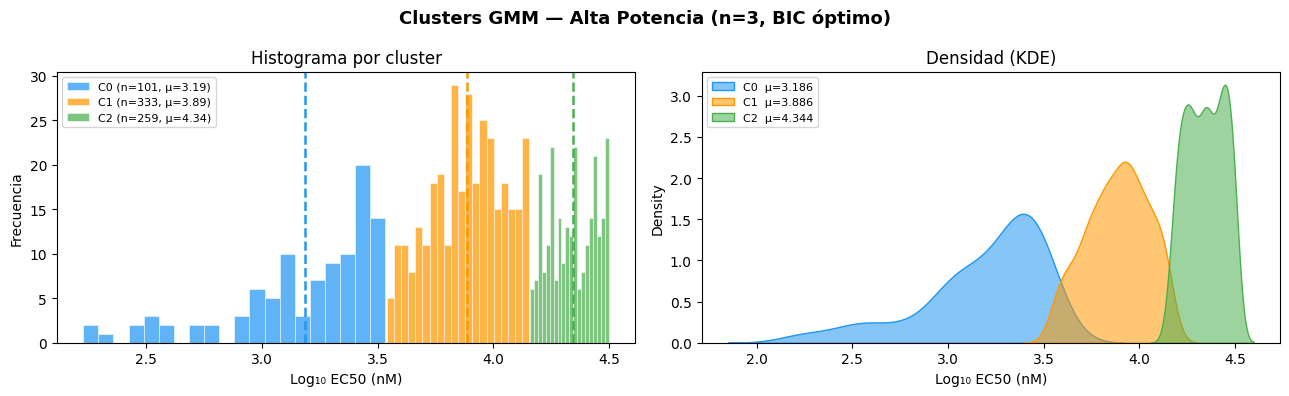

In [4]:
# ── CELDA 4 — Clustering GMM (n=3, BIC óptimo) ───────────────
print("\n── Clustering GMM (n=3) ──")

y_vals = df['log10_ec50'].values
gmm    = GaussianMixture(n_components=3, random_state=RANDOM_SEED)
gmm.fit(y_vals.reshape(-1, 1))
raw_labels = gmm.predict(y_vals.reshape(-1, 1))

# Reordenar clusters por media ascendente
order  = np.argsort(gmm.means_.flatten())
remap  = {old: new for new, old in enumerate(order)}
cluster_labels = np.array([remap[l] for l in raw_labels])

for cid in range(3):
    vals = y_vals[cluster_labels == cid]
    print(f"  Cluster {cid}: n={len(vals):4d}  "
          f"media={vals.mean():.3f}  std={vals.std():.3f}  "
          f"rango=[{vals.min():.3f}, {vals.max():.3f}]")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Clusters GMM — Alta Potencia (n=3, BIC óptimo)",
             fontsize=13, fontweight="bold")

for cid in range(3):
    vals = y_vals[cluster_labels == cid]
    axes[0].hist(vals, bins=20, color=PALETTE_C[cid], alpha=0.72,
                 edgecolor="white", linewidth=0.5,
                 label=f"C{cid} (n={len(vals)}, μ={vals.mean():.2f})")
    axes[0].axvline(vals.mean(), color=PALETTE_C[cid],
                    linestyle="--", linewidth=1.8)
    sns.kdeplot(vals, ax=axes[1], fill=True, color=PALETTE_C[cid],
                alpha=0.55, label=f"C{cid}  μ={vals.mean():.3f}")

axes[0].set_xlabel("Log₁₀ EC50 (nM)"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Histograma por cluster"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("Log₁₀ EC50 (nM)"); axes[1].set_title("Densidad (KDE)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/alta_v3_clusters.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

In [5]:
# ── CELDA 5 — Descriptores moleculares ───────────────────────
def get_descriptors(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    # Corrected lines: Convert BitVect directly to a list of integers, then to numpy array
    fp4  = np.array(list(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 1024)), dtype=float)
    fp6  = np.array(list(AllChem.GetMorganFingerprintAsBitVect(mol, 3, 1024)), dtype=float)
    maccs = np.array(list(rdMolDescriptors.GetMACCSKeysFingerprint(mol)), dtype=float)
    desc = [
        Descriptors.ExactMolWt(mol),       Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),             Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),    Descriptors.NumRotatableBonds(mol),
        Descriptors.RingCount(mol),        Descriptors.NumAromaticRings(mol),
        Descriptors.FractionCSP3(mol),     Descriptors.NumAliphaticRings(mol),
        Descriptors.NumHeteroatoms(mol),   Descriptors.HeavyAtomCount(mol),
        Descriptors.NumSaturatedRings(mol),
        rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
        rdMolDescriptors.CalcNumSpiroAtoms(mol),
    ]
    return np.concatenate([fp4, fp6, maccs, desc])

print("Calculando descriptores...")
X_list, valid_idx = [], []
for i, smi in enumerate(df['smiles']):
    d = get_descriptors(smi)
    if d is not None:
        X_list.append(d); valid_idx.append(i)

X_full  = np.array(X_list)
y_full  = df['log10_ec50'].iloc[valid_idx].values
cl_all  = cluster_labels[valid_idx]
mask    = np.isfinite(y_full)
X_full, y_full, cl_all = X_full[mask], y_full[mask], cl_all[mask]
print(f"Moléculas: {len(X_full)}  |  Features: {X_full.shape[1]}")

Calculando descriptores...


[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerator
[21:08:59] DEPRECATION WARNING: please use MorganGenerat

Moléculas: 693  |  Features: 2230


[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerator
[21:09:04] DEPRECATION WARNING: please use MorganGenerat

In [6]:
# ── CELDA 6 — Limpieza de features ───────────────────────────
vt      = VarianceThreshold(threshold=0.01)
X_vt    = vt.fit_transform(X_full)
corr    = np.corrcoef(X_vt.T)
upper_t = np.triu(np.abs(corr), k=1)
drop    = np.where(np.any(upper_t > 0.95, axis=0))[0]
keep    = np.ones(X_vt.shape[1], dtype=bool); keep[drop] = False
X_clean = X_vt[:, keep]
print(f"Features: {X_full.shape[1]} → {X_vt.shape[1]} → {X_clean.shape[1]}")

Features: 2230 → 1606 → 1372


In [7]:
# ── CELDA 7 — Split global estratificado ─────────────────────
y_bins = pd.qcut(y_full, q=5, labels=False, duplicates='drop')

X_tr_all, X_te_all, y_tr_all, y_te_all, cl_tr, cl_te = train_test_split(
    X_clean, y_full, cl_all,
    test_size=0.20, random_state=RANDOM_SEED, stratify=y_bins
)

print(f"Train: {len(y_tr_all)}  |  Test: {len(y_te_all)}")
for cid in range(3):
    print(f"  C{cid} → train={(cl_tr==cid).sum()}  test={(cl_te==cid).sum()}")

Train: 554  |  Test: 139
  C0 → train=83  test=18
  C1 → train=262  test=71
  C2 → train=209  test=50


In [8]:
# ── CELDA 8 — Función: mejor modelo por cluster ───────────────
def fit_best_model(X_tr, y_tr, cluster_name):
    n_cv = max(3, min(5, len(y_tr) // 10))
    kf_c = KFold(n_splits=n_cv, shuffle=True, random_state=RANDOM_SEED)

    candidates = {
        "GradientBoosting": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  GradientBoostingRegressor(
                n_estimators=500, learning_rate=0.02, max_depth=4,
                subsample=0.75, min_samples_leaf=3, max_features=0.5,
                random_state=RANDOM_SEED
            ))
        ]),
        "RandomForest": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  RandomForestRegressor(
                n_estimators=500, max_depth=10, max_features=0.3,
                min_samples_leaf=2, random_state=RANDOM_SEED, n_jobs=-1
            ))
        ]),
        "ExtraTrees": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  ExtraTreesRegressor(
                n_estimators=500, max_depth=10, max_features=0.3,
                min_samples_leaf=2, random_state=RANDOM_SEED, n_jobs=-1
            ))
        ]),
        "SVM": Pipeline([
            ("scaler", RobustScaler()),
            ("model",  SVR(kernel="rbf", C=50, epsilon=0.02, gamma="scale"))
        ]),
    }

    best_name, best_score, best_pipe = None, -np.inf, None
    print(f"\n  [{cluster_name}] n={len(y_tr)}  "
          f"rango=[{y_tr.min():.3f}, {y_tr.max():.3f}]  "
          f"μ={y_tr.mean():.3f}  σ={y_tr.std():.3f}")

    for mname, pipe in candidates.items():
        scores = cross_val_score(pipe, X_tr, y_tr, cv=kf_c,
                                 scoring="r2", n_jobs=-1)
        print(f"    {mname:<20}  CV R² = {scores.mean():.4f} ± {scores.std():.4f}")
        if scores.mean() > best_score:
            best_score, best_name, best_pipe = scores.mean(), mname, pipe

    print(f"  → Mejor: {best_name}  (CV R²={best_score:.4f})")
    best_pipe.fit(X_tr, y_tr)
    return best_pipe, best_name, best_score

In [9]:
# ── CELDA 9 — Entrenamiento por cluster ──────────────────────
print("=" * 60)
print("  ENTRENAMIENTO — 3 SUB-MODELOS")
print("=" * 60)

cluster_pipes   = {}
cluster_sels    = {}
cluster_results = {}

for cid in range(3):
    tr_mask = cl_tr == cid
    te_mask = cl_te == cid
    X_tr_c  = X_tr_all[tr_mask];  y_tr_c = y_tr_all[tr_mask]
    X_te_c  = X_te_all[te_mask];  y_te_c = y_te_all[te_mask]

    # Selección de features por cluster
    rf_sel = RandomForestRegressor(n_estimators=100,
                                   random_state=RANDOM_SEED, n_jobs=-1)
    rf_sel.fit(X_tr_c, y_tr_c)
    sel      = SelectFromModel(rf_sel, threshold="mean", prefit=True)
    X_tr_sel = sel.transform(X_tr_c)
    X_te_sel = sel.transform(X_te_c)
    print(f"\n  Cluster {cid}: {X_tr_c.shape[1]} → {X_tr_sel.shape[1]} features")

    pipe, name, cv_r2 = fit_best_model(X_tr_sel, y_tr_c, f"Cluster {cid}")

    y_pred_tr = pipe.predict(X_tr_sel)
    y_pred_te = pipe.predict(X_te_sel)
    r2_tr  = r2_score(y_tr_c, y_pred_tr)
    r2_te  = r2_score(y_te_c, y_pred_te)
    rmse   = np.sqrt(mean_squared_error(y_te_c, y_pred_te))
    mae    = mean_absolute_error(y_te_c, y_pred_te)

    cluster_pipes[cid]   = pipe
    cluster_sels[cid]    = sel
    cluster_results[cid] = {
        "model_name": name, "cv_r2": cv_r2,
        "r2_train": r2_tr, "r2_test": r2_te,
        "rmse": rmse, "mae": mae, "gap": r2_tr - r2_te,
        "y_tr": y_tr_c, "y_pred_tr": y_pred_tr,
        "y_te": y_te_c, "y_pred_te": y_pred_te,
    }

    print(f"\n  ── Cluster {cid} ({name}) ──")
    print(f"     CV R²    = {cv_r2:.4f}")
    print(f"     Train R² = {r2_tr:.4f}  |  Test R² = {r2_te:.4f}  |  Gap = {r2_tr-r2_te:.4f}")
    print(f"     RMSE = {rmse:.4f}  |  MAE = {mae:.4f}")
    print(f"     {'✅ R² ≥ 0.70' if r2_te >= 0.70 else f'⚠️  R² = {r2_te:.4f}'}")

  ENTRENAMIENTO — 3 SUB-MODELOS

  Cluster 0: 1372 → 165 features

  [Cluster 0] n=83  rango=[2.230, 3.534]  μ=3.177  σ=0.327
    GradientBoosting      CV R² = 0.1868 ± 0.2508
    RandomForest          CV R² = 0.3020 ± 0.2501
    ExtraTrees            CV R² = 0.3000 ± 0.2248
    SVM                   CV R² = 0.2287 ± 0.1915
  → Mejor: RandomForest  (CV R²=0.3020)

  ── Cluster 0 (RandomForest) ──
     CV R²    = 0.3020
     Train R² = 0.7393  |  Test R² = 0.0726  |  Gap = 0.6668
     RMSE = 0.2502  |  MAE = 0.1932
     ⚠️  R² = 0.0726

  Cluster 1: 1372 → 214 features

  [Cluster 1] n=262  rango=[3.540, 4.155]  μ=3.890  σ=0.155
    GradientBoosting      CV R² = 0.4386 ± 0.0712
    RandomForest          CV R² = 0.4292 ± 0.0287
    ExtraTrees            CV R² = 0.4343 ± 0.0382
    SVM                   CV R² = 0.4439 ± 0.0263
  → Mejor: SVM  (CV R²=0.4439)

  ── Cluster 1 (SVM) ──
     CV R²    = 0.4439
     Train R² = 0.8800  |  Test R² = 0.3781  |  Gap = 0.5019
     RMSE = 0.1361  |  M

In [10]:
# ── CELDA 10 — Resultado global combinado ─────────────────────
y_pred_global    = np.zeros(len(y_te_all))
y_pred_tr_global = np.zeros(len(y_tr_all))

for cid in range(3):
    y_pred_global[cl_te == cid] = cluster_pipes[cid].predict(
        cluster_sels[cid].transform(X_te_all[cl_te == cid])
    )
    y_pred_tr_global[cl_tr == cid] = cluster_pipes[cid].predict(
        cluster_sels[cid].transform(X_tr_all[cl_tr == cid])
    )

r2_gl_tr  = r2_score(y_tr_all, y_pred_tr_global)
r2_gl_te  = r2_score(y_te_all, y_pred_global)
rmse_gl   = np.sqrt(mean_squared_error(y_te_all, y_pred_global))
mae_gl    = mean_absolute_error(y_te_all, y_pred_global)

print(f"\n{'─'*60}")
print(f"  RESULTADO GLOBAL (tres sub-modelos combinados)")
print(f"{'─'*60}")
print(f"  Train R² = {r2_gl_tr:.4f}")
print(f"  Test  R² = {r2_gl_te:.4f}")
print(f"  RMSE     = {rmse_gl:.4f}  |  MAE = {mae_gl:.4f}")
print(f"  {'✅ META ALCANZADA: R² ≥ 0.70' if r2_gl_te >= 0.70 else f'⚠️  R² = {r2_gl_te:.4f}'}")
print(f"\n  Comparativa:")
print(f"  v2 modelo único  : Test R² = 0.4587")
print(f"  v3 GMM 3 clusters: Test R² = {r2_gl_te:.4f}  ({r2_gl_te-0.4587:+.4f})")


────────────────────────────────────────────────────────────
  RESULTADO GLOBAL (tres sub-modelos combinados)
────────────────────────────────────────────────────────────
  Train R² = 0.9627
  Test  R² = 0.8734
  RMSE     = 0.1410  |  MAE = 0.0966
  ✅ META ALCANZADA: R² ≥ 0.70

  Comparativa:
  v2 modelo único  : Test R² = 0.4587
  v3 GMM 3 clusters: Test R² = 0.8734  (+0.4147)


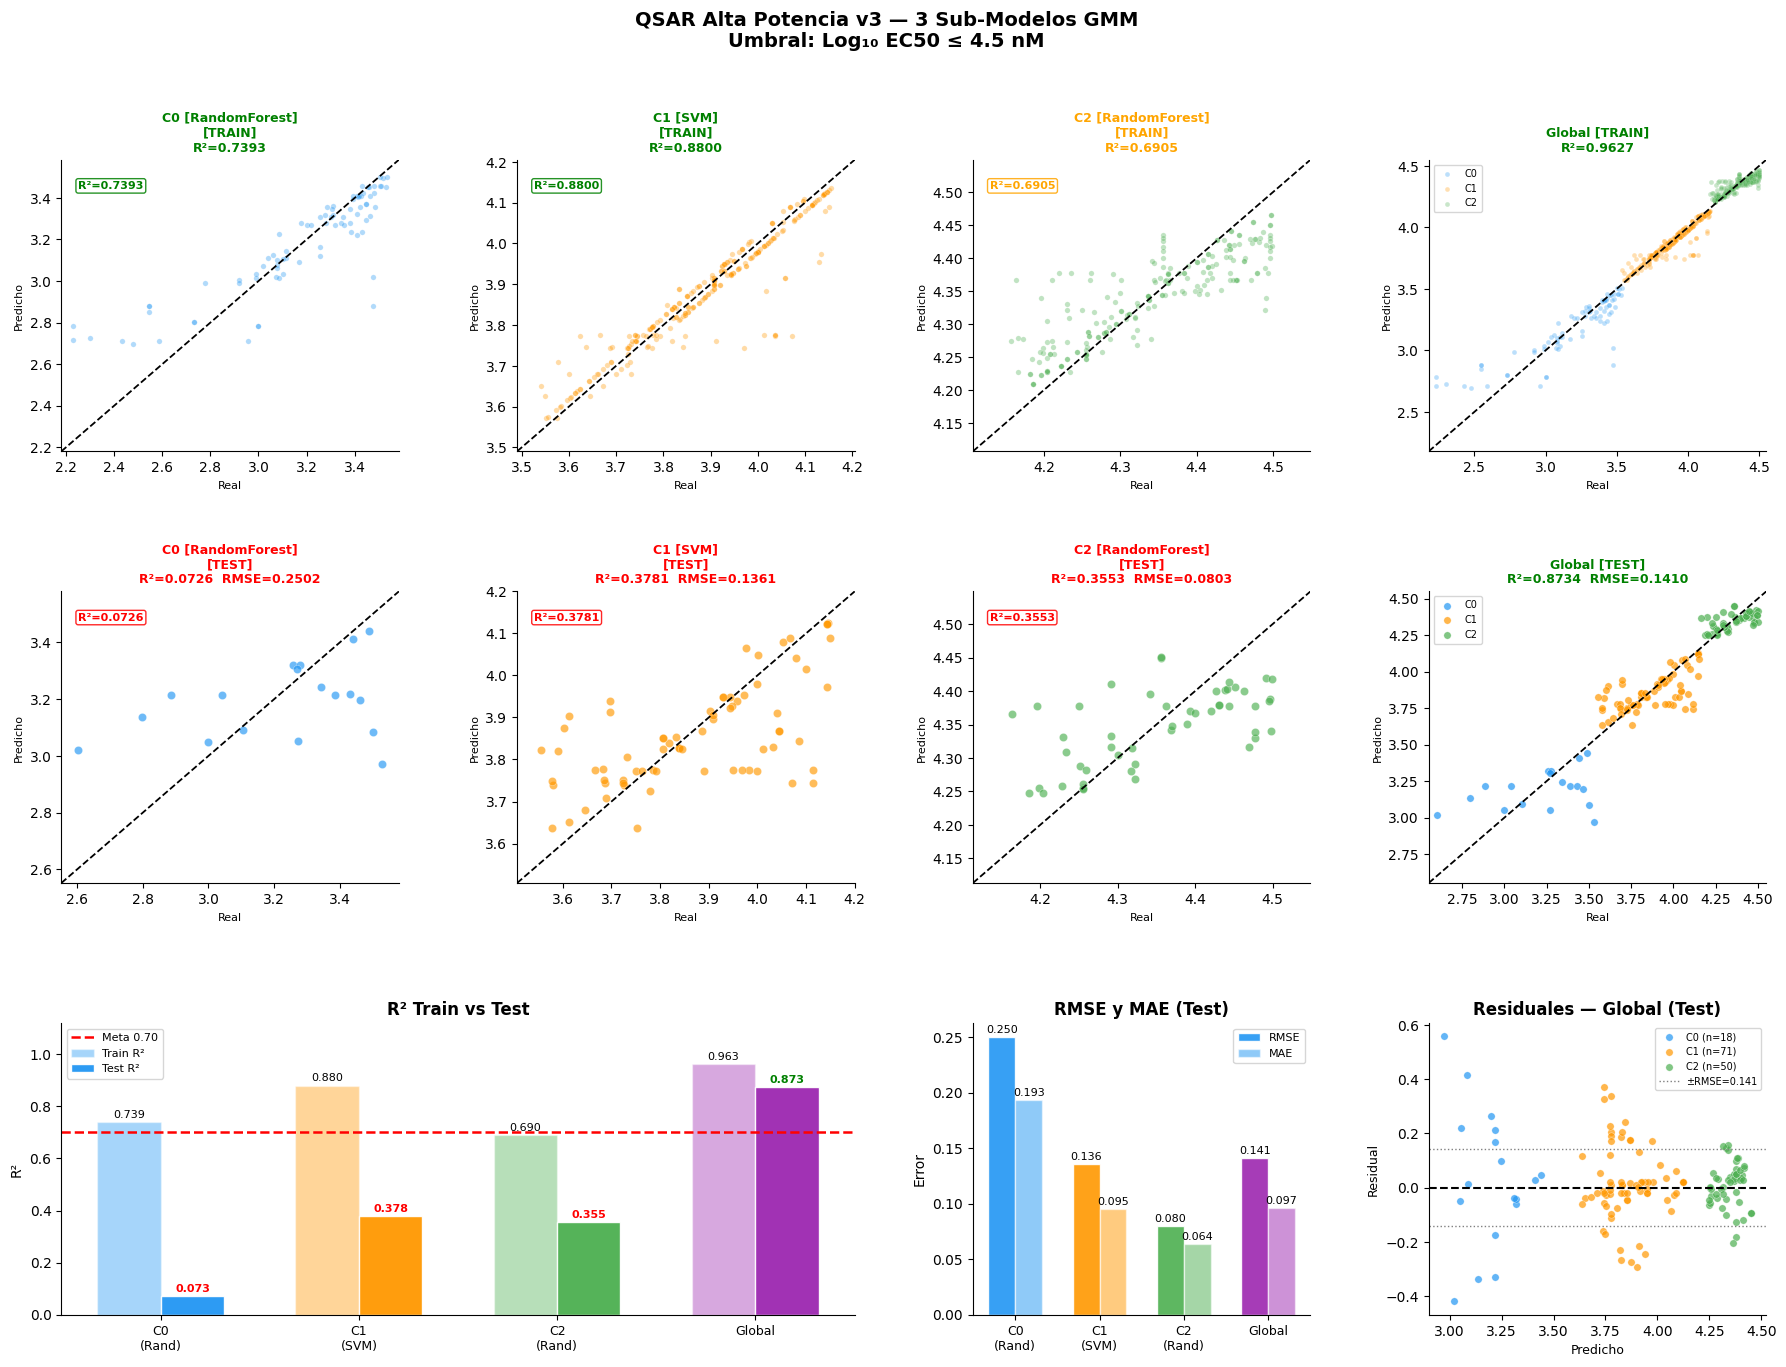

In [11]:
# ── CELDA 11 — Gráfica completa ───────────────────────────────
fig = plt.figure(figsize=(22, 15))
fig.suptitle("QSAR Alta Potencia v3 — 3 Sub-Modelos GMM\n"
             "Umbral: Log₁₀ EC50 ≤ 4.5 nM",
             fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.35)

def scatter_ax(ax, yr, yp, color, title, r2, rmse=None, alpha=0.65, s=35):
    ax.scatter(yr, yp, color=color, alpha=alpha,
               edgecolors="white", linewidth=0.3, s=s)
    lo = min(yr.min(), yp.min()) - 0.05
    hi = max(yr.max(), yp.max()) + 0.05
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.3)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("Real", fontsize=8); ax.set_ylabel("Predicho", fontsize=8)
    col = "green" if r2 >= 0.70 else ("orange" if r2 >= 0.50 else "red")
    lbl = f"R²={r2:.4f}" + (f"  RMSE={rmse:.4f}" if rmse else "")
    ax.set_title(f"{title}\n{lbl}", fontsize=9, fontweight="bold", color=col)
    ax.text(0.05, 0.90, f"R²={r2:.4f}", transform=ax.transAxes,
            fontsize=8, color=col, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                      edgecolor=col, alpha=0.85))
    ax.spines[["top","right"]].set_visible(False)

# Fila 1: TRAIN por cluster
for cid in range(3):
    cr = cluster_results[cid]
    scatter_ax(fig.add_subplot(gs[0, cid]),
               cr["y_tr"], cr["y_pred_tr"], PALETTE_C[cid],
               f"C{cid} [{cr['model_name']}]\n[TRAIN]",
               cr["r2_train"], alpha=0.35, s=15)

# Global TRAIN
ax_gtr = fig.add_subplot(gs[0, 3])
for cid in range(3):
    m = cl_tr == cid
    ax_gtr.scatter(y_tr_all[m], y_pred_tr_global[m],
                   color=PALETTE_C[cid], alpha=0.3, s=12,
                   edgecolors="white", linewidth=0.2, label=f"C{cid}")
lo = min(y_tr_all.min(), y_pred_tr_global.min()) - 0.05
hi = max(y_tr_all.max(), y_pred_tr_global.max()) + 0.05
ax_gtr.plot([lo,hi],[lo,hi],"k--",linewidth=1.3)
ax_gtr.set_xlim(lo,hi); ax_gtr.set_ylim(lo,hi)
ax_gtr.set_xlabel("Real",fontsize=8); ax_gtr.set_ylabel("Predicho",fontsize=8)
col = "green" if r2_gl_tr >= 0.70 else "orange"
ax_gtr.set_title(f"Global [TRAIN]\nR²={r2_gl_tr:.4f}",
                 fontsize=9, fontweight="bold", color=col)
ax_gtr.legend(fontsize=7); ax_gtr.spines[["top","right"]].set_visible(False)

# Fila 2: TEST por cluster
for cid in range(3):
    cr = cluster_results[cid]
    scatter_ax(fig.add_subplot(gs[1, cid]),
               cr["y_te"], cr["y_pred_te"], PALETTE_C[cid],
               f"C{cid} [{cr['model_name']}]\n[TEST]",
               cr["r2_test"], cr["rmse"])

# Global TEST
ax_gte = fig.add_subplot(gs[1, 3])
for cid in range(3):
    m = cl_te == cid
    ax_gte.scatter(y_te_all[m], y_pred_global[m],
                   color=PALETTE_C[cid], alpha=0.7, s=28,
                   edgecolors="white", linewidth=0.3, label=f"C{cid}")
lo = min(y_te_all.min(), y_pred_global.min()) - 0.05
hi = max(y_te_all.max(), y_pred_global.max()) + 0.05
ax_gte.plot([lo,hi],[lo,hi],"k--",linewidth=1.3)
ax_gte.set_xlim(lo,hi); ax_gte.set_ylim(lo,hi)
ax_gte.set_xlabel("Real",fontsize=8); ax_gte.set_ylabel("Predicho",fontsize=8)
col = "green" if r2_gl_te >= 0.70 else "orange"
ax_gte.set_title(f"Global [TEST]\nR²={r2_gl_te:.4f}  RMSE={rmse_gl:.4f}",
                 fontsize=9, fontweight="bold", color=col)
ax_gte.legend(fontsize=7); ax_gte.spines[["top","right"]].set_visible(False)

# Fila 3 — R² barras
labels_b = [f"C{i}\n({cluster_results[i]['model_name'][:4]})" for i in range(3)] + ["Global"]
r2_trs_b = [cluster_results[i]["r2_train"] for i in range(3)] + [r2_gl_tr]
r2_tes_b = [cluster_results[i]["r2_test"]  for i in range(3)] + [r2_gl_te]
cols_b   = PALETTE_C + ["#9C27B0"]
x_b, w   = np.arange(4), 0.32

ax_r2 = fig.add_subplot(gs[2, 0:2])
b1 = ax_r2.bar(x_b-w/2, r2_trs_b, w, color=cols_b, alpha=0.4,
                edgecolor="white", label="Train R²")
b2 = ax_r2.bar(x_b+w/2, r2_tes_b, w, color=cols_b, alpha=0.95,
                edgecolor="white", label="Test R²")
for bar, val in zip(b1, r2_trs_b):
    ax_r2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
               f"{val:.3f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(b2, r2_tes_b):
    c = "green" if val >= 0.70 else ("orange" if val >= 0.50 else "red")
    ax_r2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
               f"{val:.3f}", ha="center", va="bottom",
               fontsize=8, fontweight="bold", color=c)
ax_r2.axhline(0.70, color="red", linestyle="--", linewidth=1.8, label="Meta 0.70")
ax_r2.set_xticks(x_b); ax_r2.set_xticklabels(labels_b, fontsize=9)
ax_r2.set_ylabel("R²"); ax_r2.set_title("R² Train vs Test", fontweight="bold")
ax_r2.set_ylim(0, 1.12); ax_r2.legend(fontsize=8)
ax_r2.spines[["top","right"]].set_visible(False)

# RMSE y MAE
ax_err = fig.add_subplot(gs[2, 2])
rmse_b = [cluster_results[i]["rmse"] for i in range(3)] + [rmse_gl]
mae_b  = [cluster_results[i]["mae"]  for i in range(3)] + [mae_gl]
b3 = ax_err.bar(x_b-w/2, rmse_b, w, color=cols_b, alpha=0.9,
                edgecolor="white", label="RMSE")
b4 = ax_err.bar(x_b+w/2, mae_b,  w, color=cols_b, alpha=0.5,
                edgecolor="white", label="MAE")
for bar, val in zip(b3, rmse_b):
    ax_err.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(b4, mae_b):
    ax_err.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax_err.set_xticks(x_b); ax_err.set_xticklabels(labels_b, fontsize=9)
ax_err.set_ylabel("Error"); ax_err.set_title("RMSE y MAE (Test)", fontweight="bold")
ax_err.legend(fontsize=8); ax_err.spines[["top","right"]].set_visible(False)

# Residuales global
ax_res = fig.add_subplot(gs[2, 3])
res_gl = y_te_all - y_pred_global
for cid in range(3):
    m = cl_te == cid
    ax_res.scatter(y_pred_global[m], res_gl[m], color=PALETTE_C[cid],
                   alpha=0.7, s=28, edgecolors="white", linewidth=0.3,
                   label=f"C{cid} (n={m.sum()})")
ax_res.axhline(0, color="black", linestyle="--", linewidth=1.5)
ax_res.axhline( rmse_gl, color="gray", linestyle=":", linewidth=1,
                label=f"±RMSE={rmse_gl:.3f}")
ax_res.axhline(-rmse_gl, color="gray", linestyle=":", linewidth=1)
ax_res.set_xlabel("Predicho",fontsize=9); ax_res.set_ylabel("Residual",fontsize=9)
ax_res.set_title("Residuales — Global (Test)", fontweight="bold")
ax_res.legend(fontsize=7); ax_res.spines[["top","right"]].set_visible(False)

plt.savefig(
    "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/alta_v3_resultados_completos.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

In [12]:
# ── CELDA 12 — Guardar modelos ────────────────────────────────
import os, joblib # Added import os
CARPETA = "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/modelos"
os.makedirs(CARPETA, exist_ok=True)

for cid in range(3):
    joblib.dump(cluster_pipes[cid],
                os.path.join(CARPETA, f"pipe_Alta_v3_c{cid}.pkl"))
    joblib.dump(cluster_sels[cid],
                os.path.join(CARPETA, f"sel_Alta_v3_c{cid}.pkl"))
joblib.dump(vt,  os.path.join(CARPETA, "vt_Alta_v3.pkl"))
joblib.dump(gmm, os.path.join(CARPETA, "gmm_Alta_v3.pkl"))
joblib.dump(keep, os.path.join(CARPETA, "keep_Alta_v3.pkl")) # Added line to save the 'keep' mask

print(f"✅ Modelos guardados en {CARPETA}/")
for cid in range(3):
    print(f"   pipe_Alta_v3_c{cid}.pkl  ({cluster_results[cid]['model_name']})")

✅ Modelos guardados en /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/modelos/
   pipe_Alta_v3_c0.pkl  (RandomForest)
   pipe_Alta_v3_c1.pkl  (SVM)
   pipe_Alta_v3_c2.pkl  (RandomForest)


In [13]:
# ── CELDA 13 — Resumen final ──────────────────────────────────
print("\n" + "="*65)
print("  RESUMEN FINAL — QSAR Alta Potencia v3")
print("="*65)
print(f"  {'':25} {'Train R²':>9} {'Test R²':>9} {'RMSE':>8} {'MAE':>8}")
print("  " + "─"*62)
for cid in range(3):
    cr   = cluster_results[cid]
    flag = "✅" if cr["r2_test"] >= 0.70 else ("🟡" if cr["r2_test"] >= 0.50 else "  ")
    print(f"  Cluster {cid} ({cr['model_name']:<15}) "
          f"{cr['r2_train']:>9.4f} {cr['r2_test']:>9.4f} "
          f"{cr['rmse']:>8.4f} {cr['mae']:>8.4f}  {flag}")
flag_gl = "✅" if r2_gl_te >= 0.70 else "🟡"
print(f"  {'Global combinado':<25} {r2_gl_tr:>9.4f} {r2_gl_te:>9.4f} "
      f"{rmse_gl:>8.4f} {mae_gl:>8.4f}  {flag_gl}")
print("="*65)
print(f"\n  Evolución Alta Potencia:")
print(f"    Stacking anterior (232 mol): Test R² = 0.8280")
print(f"    v2 modelo único  (693 mol): Test R² = 0.4587")
print(f"    v3 GMM 3 clusters(693 mol): Test R² = {r2_gl_te:.4f}")
print(f"\n📁 Archivos generados:")
print(f"   alta_v3_clusters.png")
print(f"   alta_v3_resultados_completos.png")
print(f"   modelos/ → pipe_Alta_v3_c0/1/2.pkl")
print(f"              vt_Alta_v3.pkl, gmm_Alta_v3.pkl")


  RESUMEN FINAL — QSAR Alta Potencia v3
                             Train R²   Test R²     RMSE      MAE
  ──────────────────────────────────────────────────────────────
  Cluster 0 (RandomForest   )    0.7393    0.0726   0.2502   0.1932    
  Cluster 1 (SVM            )    0.8800    0.3781   0.1361   0.0951    
  Cluster 2 (RandomForest   )    0.6905    0.3553   0.0803   0.0639    
  Global combinado             0.9627    0.8734   0.1410   0.0966  ✅

  Evolución Alta Potencia:
    Stacking anterior (232 mol): Test R² = 0.8280
    v2 modelo único  (693 mol): Test R² = 0.4587
    v3 GMM 3 clusters(693 mol): Test R² = 0.8734

📁 Archivos generados:
   alta_v3_clusters.png
   alta_v3_resultados_completos.png
   modelos/ → pipe_Alta_v3_c0/1/2.pkl
              vt_Alta_v3.pkl, gmm_Alta_v3.pkl


In [14]:
# ============================================================
# CELDA PREDICTOR — ALTA POTENCIA (Adaptado para v3 GMM)
# Predicción usando el ensemble de 3 sub-modelos GMM.
# ============================================================

import os, joblib
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Crippen, Descriptors, Lipinski
from rdkit.Chem import rdMolDescriptors, GraphDescriptors
from sklearn.base import clone

# __ CONFIGURACIÓN _____________________________________________
POTENCIA = "Alta_v3_GMM"

CONJUNTOS = [
    {
        "nombre":     "cannabaceae_complete",
        "entrada":    "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/cannabaceae_phytochemicals_complete.csv",
        "salida":     "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_alta_v3_cannabaceae_complete.csv",
        "sep":        ",",
        "col_smiles": "smiles",
        "col_nombre": "molecule_name",
    },
    {
        "nombre":     "cannabaceae_hoja1",
        "entrada":    "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/Cannabaceae_molecules(Hoja1).csv",
        "salida":     "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_alta_v3_cannabaceae_hoja1.csv",
        "sep":        ";",
        "col_smiles": "Smiles",
        "col_nombre": "Molecule_name",
    },
    {
        "nombre":     "terpenos",
        "entrada":    "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/terpenos.csv",
        "salida":     "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_alta_v3_terpenos.csv",
        "sep":        ";",
        "col_smiles": "Smiles",
        "col_nombre": "Molecule_name",
    },{
        "nombre":     "molecules3",
        "entrada":    "/content/drive/MyDrive/degree_project/scripts/1.general_model/datasources/molecules3.csv",
        "salida":     "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_alta_moleculas.csv",
        "sep":        ";",
        "col_smiles": "Smiles",
        "col_nombre": "Molecule_name",
    },]

CARPETA_MODELOS = "/content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/modelos"
N_BOOTSTRAP     = 200 # Not used for CI in v3 ensemble, but kept for consistency if needed.
os.makedirs(CARPETA_MODELOS, exist_ok=True)

# __ Cargar modelos V3 _________________________________________
# Cargar GMM para posible uso futuro (aunque no se usa directamente para clusterizar X)
# Se carga el VarianceThreshold global
# Se cargan los pipelines y selectores por cluster

try:
    gmm = joblib.load(os.path.join(CARPETA_MODELOS, "gmm_Alta_v3.pkl"))
    vt = joblib.load(os.path.join(CARPETA_MODELOS, "vt_Alta_v3.pkl"))
    # Load the 'keep' mask for correlation filtering
    keep = joblib.load(os.path.join(CARPETA_MODELOS, "keep_Alta_v3.pkl")) # Assuming this file is saved during training
    cluster_pipes = {}
    cluster_sels = {}
    for cid in range(3):
        cluster_pipes[cid] = joblib.load(os.path.join(CARPETA_MODELOS, f"pipe_Alta_v3_c{cid}.pkl"))
        cluster_sels[cid] = joblib.load(os.path.join(CARPETA_MODELOS, f"sel_Alta_v3_c{cid}.pkl"))
    print(f"✅ Modelos V3 cargados de {CARPETA_MODELOS}")
except Exception as e:
    print(f"❌ Error al cargar modelos V3: {e}")
    print("Asegúrate de haber ejecutado las celdas de entrenamiento de la v3.")
    exit() # Exit if models cannot be loaded

# __ Descriptores (corregidos para compatibilidad con RDKit) __
def count_double_bonds(mol):
    return sum(1 for b in mol.GetBonds()
               if b.GetBondType() == Chem.BondType.DOUBLE and not b.GetIsAromatic())

def safe_descriptor_calc(mol):
    try:
        # Ensure these match the training descriptor generation exactly
        fp4  = np.array(list(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 1024)), dtype=float)
        fp6  = np.array(list(AllChem.GetMorganFingerprintAsBitVect(mol, 3, 1024)), dtype=float)
        maccs = np.array(list(rdMolDescriptors.GetMACCSKeysFingerprint(mol)), dtype=float)
        desc = [
            Descriptors.ExactMolWt(mol),       Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol),             Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol),    Descriptors.NumRotatableBonds(mol),
            Descriptors.RingCount(mol),        Descriptors.NumAromaticRings(mol),
            Descriptors.FractionCSP3(mol),     Descriptors.NumAliphaticRings(mol),
            Descriptors.NumHeteroatoms(mol),   Descriptors.HeavyAtomCount(mol),
            Descriptors.NumSaturatedRings(mol),
            rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
            rdMolDescriptors.CalcNumSpiroAtoms(mol),
        ]
        return np.concatenate([fp4, fp6, maccs, desc])
    except Exception as e:
        # print(f"Error calculando descriptores para SMILES: {e}") # Uncomment for debugging
        return None

def calcular_features(smiles_list):
    X, valid_idx = [], []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(str(smi))
        if mol:
            desc = safe_descriptor_calc(mol)
            if desc is not None:
                X.append(desc); valid_idx.append(i)
    return np.array(X), valid_idx

# __ Cargar CSV con detección automática de separador __________
def cargar_csv(ruta, sep, col_smi_cfg, col_nom_cfg):
    try:
        df = pd.read_csv(ruta, sep=sep)
        if df.shape[1] == 1: # Si solo hay una columna, el separador es incorrecto
            sep2 = "," if sep == ";" else ";"
            df   = pd.read_csv(ruta, sep=sep2)
            print(f"  ⚠️  Separador ajustado a '{sep2}'")
    except Exception as e:
        raise RuntimeError(f"No se pudo leer {ruta}: {e}")

    df.columns = df.columns.str.strip()

    col_smi = col_smi_cfg
    col_nom = col_nom_cfg
    # Intentar detectar la columna SMILES y Nombre automáticamente
    for p in ['smiles', 'Smiles', 'SMILES']:
        if p in df.columns: col_smi = p; break
    for p in ['molecule_name', 'Molecule_name', 'Molecule_Name', 'name', 'Name', 'Compound']:
        if p in df.columns: col_nom = p; break

    print(f"  Columnas → SMILES: '{col_smi}'   Nombre: '{col_nom}'")
    return df, col_smi, col_nom

# __ Procesar cada conjunto ____________________________________
for cfg in CONJUNTOS:
    print(f"\n{'='*60}")
    print(f"  {POTENCIA} — {cfg['nombre']}")
    print(f"{'='*60}")

    try:
        df_new, col_smi, col_nom = cargar_csv(
            cfg['entrada'], cfg['sep'], cfg['col_smiles'], cfg['col_nombre']
        )
    except RuntimeError as e:
        print(f"  ❌ {e}"); continue

    print(f"  Moléculas cargadas: {len(df_new)}")

    # Calcular descriptores
    X_raw, valid_idx = calcular_features(df_new[col_smi].tolist())
    df_valid = df_new.iloc[valid_idx].reset_index(drop=True)
    n_inv = len(df_new) - len(df_valid)
    if n_inv:
        print(f"  ⚠️  {n_inv} SMILES inválidos o con error de descriptor descartados")
    print(f"  Moléculas válidas: {len(df_valid)}")

    if len(df_valid) == 0:
        print("  No hay moléculas válidas para predecir. Saltando...")
        continue

    # Preprocesar globalmente con VarianceThreshold
    X_vt_new = vt.transform(X_raw)
    print(f"  Dimensiones tras VarianceThreshold: {X_vt_new.shape}")

    # Aplicar el mismo filtro de correlación que durante el entrenamiento
    X_corr_filtered_new = X_vt_new[:, keep]
    print(f"  Dimensiones tras filtro correlación: {X_corr_filtered_new.shape}")

    # Generar predicciones de cada sub-modelo
    predictions_all_models = np.zeros((len(df_valid), 3))
    for cid in range(3):
        # Usar X_corr_filtered_new que tiene el número correcto de features
        X_sel_c = cluster_sels[cid].transform(X_corr_filtered_new)
        predictions_all_models[:, cid] = cluster_pipes[cid].predict(X_sel_c)

    # Predicción final: Promedio de los 3 modelos
    y_pred = np.mean(predictions_all_models, axis=1)

    # Calcular una estimación de la desviación estándar para el CI
    # Como alternativa a bootstrap completo, usamos la std de las 3 predicciones
    std_pred = np.std(predictions_all_models, axis=1)
    z = 1.96 # Para CI del 95%
    ci_hw = z * std_pred
    lower = y_pred - ci_hw
    upper = y_pred + ci_hw
    width = upper - lower

    # Guardar
    df_out = pd.DataFrame({
        "SMILES":                   df_valid[col_smi].values,
        "Molecule_name":            df_valid[col_nom].values,
        "Potency_Model":            POTENCIA,
        "Predicted_Log10_Value_nM": y_pred,
        "Lower_CI_95":              lower,
        "Upper_CI_95":              upper,
        "CI_95_Width":              width,
    })

    os.makedirs(os.path.dirname(cfg['salida']), exist_ok=True)
    df_out.to_csv(cfg['salida'], sep=";", index=False, float_format="%.6f")

    print(f"  ✅ Guardado: {cfg['salida']}")
    print(f"  Pred. media: {y_pred.mean():.4f} | "
          f"CI width (media): {width.mean():.4f} | "
          f"Rango: [{y_pred.min():.3f}, {y_pred.max():.3f}]")
    print(f"\n  Top 5 mol\u00e9culas m\u00e1s activas (menor Log10 EC50):")
    top5 = df_out.nsmallest(5, "Predicted_Log10_Value_nM")
    print(top5[["Molecule_name", "Predicted_Log10_Value_nM",
                "CI_95_Width"]].to_string(index=False))

print(f"\n{'='*60}")
print(f"✅ Alta Potencia v3 GMM — todos los conjuntos procesados.")
print(f"{'='*60}")
print(f"\nArchivos generados:")
for cfg in CONJUNTOS:
    print(f"  → {os.path.basename(cfg['salida'])}")
print(f"\nCarpeta: /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/")

✅ Modelos V3 cargados de /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/modelos

  Alta_v3_GMM — cannabaceae_complete
  Columnas → SMILES: 'smiles'   Nombre: 'molecule_name'
  Moléculas cargadas: 597


[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerator
[21:10:14] DEPRECATION WARNING: please use MorganGenerat

  Moléculas válidas: 597
  Dimensiones tras VarianceThreshold: (597, 1606)
  Dimensiones tras filtro correlación: (597, 1372)
  ✅ Guardado: /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_alta_v3_cannabaceae_complete.csv
  Pred. media: 3.7555 | CI width (media): 2.0491 | Rango: [3.618, 3.929]

  Top 5 moléculas más activas (menor Log10 EC50):
Molecule_name  Predicted_Log10_Value_nM  CI_95_Width
    Quercetin                  3.617627     2.462963
    Quercetin                  3.617627     2.462963
    Quercetin                  3.617627     2.462963
Ascorbic acid                  3.619935     2.699859
Ascorbic acid                  3.619935     2.699859

  Alta_v3_GMM — cannabaceae_hoja1
  Columnas → SMILES: 'Smiles'   Nombre: 'Molecule_name'
  Moléculas cargadas: 45


[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerator
[21:10:18] DEPRECATION WARNING: please use MorganGenerat

  Moléculas válidas: 45
  Dimensiones tras VarianceThreshold: (45, 1606)
  Dimensiones tras filtro correlación: (45, 1372)
  ✅ Guardado: /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_alta_v3_cannabaceae_hoja1.csv
  Pred. media: 3.7820 | CI width (media): 1.9538 | Rango: [3.749, 3.816]

  Top 5 moléculas más activas (menor Log10 EC50):
Molecule_name  Predicted_Log10_Value_nM  CI_95_Width
         CBDA                  3.749445     2.056790
         CBDA                  3.749445     2.056790
         CBDA                  3.749445     2.056790
         CBDA                  3.749445     2.056790
         THCV                  3.759455     1.981117

  Alta_v3_GMM — terpenos
  ⚠️  Separador ajustado a ','
  Columnas → SMILES: 'Smiles'   Nombre: 'Molecule_name'
  Moléculas cargadas: 999


[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerator
[21:10:19] DEPRECATION WARNING: please use MorganGenerat

  ⚠️  915 SMILES inválidos o con error de descriptor descartados
  Moléculas válidas: 84
  Dimensiones tras VarianceThreshold: (84, 1606)
  Dimensiones tras filtro correlación: (84, 1372)
  ✅ Guardado: /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_alta_v3_terpenos.csv
  Pred. media: 3.7145 | CI width (media): 2.1110 | Rango: [3.686, 3.766]

  Top 5 moléculas más activas (menor Log10 EC50):
           Molecule_name  Predicted_Log10_Value_nM  CI_95_Width
             alfa-Pineno                  3.685904     2.124878
             alfa-Pineno                  3.685904     2.124878
             alfa-Pineno                  3.685904     2.124878
             alfa-Pineno                  3.685904     2.124878
(-)-Oxido de Cariofileno                  3.694157     2.193957

  Alta_v3_GMM — molecules3
  Columnas → SMILES: 'Smiles'   Nombre: 'Molecule_name'
  Moléculas cargadas: 204


[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerator
[21:10:20] DEPRECATION WARNING: please use MorganGenerat

  Moléculas válidas: 204
  Dimensiones tras VarianceThreshold: (204, 1606)
  Dimensiones tras filtro correlación: (204, 1372)
  ✅ Guardado: /content/drive/MyDrive/degree_project/scripts/Prueba_de_modelos/resultados/pred_alta_moleculas.csv
  Pred. media: 3.7721 | CI width (media): 2.0260 | Rango: [3.618, 3.929]

  Top 5 moléculas más activas (menor Log10 EC50):
      Molecule_name  Predicted_Log10_Value_nM  CI_95_Width
          Quercetin                  3.617627     2.462963
    Erythorbic Acid                  3.619935     2.699859
    L-Ascorbic Acid                  3.619935     2.699859
Quercetin Dihydrate                  3.622963     2.428852
        Citric Acid                  3.634327     2.694720

✅ Alta Potencia v3 GMM — todos los conjuntos procesados.

Archivos generados:
  → pred_alta_v3_cannabaceae_complete.csv
  → pred_alta_v3_cannabaceae_hoja1.csv
  → pred_alta_v3_terpenos.csv
  → pred_alta_moleculas.csv

Carpeta: /content/drive/MyDrive/degree_project/scripts/Prueba_de